# Google Colab Setting

In [ ]:
!pip install -q "numpy<2.0" "pandas<2.2" refinitiv-data fredapi optuna xgboost tqdm scikit-learn

# Package imports

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [4]:
import pandas as pd
import numpy as np
import refinitiv.data as rd
from fredapi import Fred

import datetime as dt
import json
import os
import joblib

from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21:TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# Data Acquisition

In [5]:
START = "2000-01-01"
END = dt.datetime.today().strftime("%Y-%m-%d")

REFINITIV_TICKERS = ["SPY", "TLT.O", "GLD", "XLE", ".DXY"]
TARGET_TICKERS = ["SPY", "TLT.O", "GLD", "XLE"]

FRED_TICKERS = {
    "T10Y2Y":     "Term_Spread",
    "BAA10Y":     "Credit_Spread",
    "T10YIE":     "Breakeven_Inflation",
    "VIXCLS":     "VIX",
    "NASDAQXAU":  "Gold_Spot",
    "DCOILWTICO": "WTI_Crude",
}

OUT_PATH = "../data/merged_daily.csv"
DATASET_DIR = "../data"

MACRO_LEVEL_DIFF = ["Term_Spread", "Credit_Spread", "Breakeven_Inflation", "VIX"]
MACRO_LOG_RETURN = ["Gold_Spot", "WTI_Crude"]


In [6]:
def key_loader(filepath):
    try:
        with open(filepath) as f:
            app_key = json.load(f)['sessions']['platform']['rdp']['app-key']
        print("Key loaded successfully")
        return app_key
    except FileNotFoundError:
        print(f"Error: '{filepath}' not found.")
        raise
    except KeyError as e:
        print(f"Error: missing key {e}.")
        raise


In [7]:
def check_state(state, message, session):
    print(f"State: {state}")
    print(f"Message: {message}")
    print("\n")

In [8]:
def fetch_refinitiv_data(tickers, start_date, end_date, app_key):
    """
    Fetch target assets' OHLCV and adjusted prices from Refinitiv Data API.
    
    :param tickers: list of ticker symbols
    :param start_date: start date (YYYY-MM-DD)
    :param end_date: end date (YYYY-MM-DD)
    :param app_key: Refinitiv app key
    :return: DataFrame with OHLCV data
    """
    session = None
    try:
        session = rd.session.desktop.Definition(app_key=app_key).get_session()
        rd.session.set_default(session)
        session.on_state(check_state)
        session.open()

        fields = [
            "TR.PriceOpen",
            "TR.PriceHigh",
            "TR.PriceLow",
            "TR.PriceClose",
            "TR.Volume"
        ]

        frames = []
        for ticker in tickers:
            print(f"[REFINITIV] Fetching {ticker} ...")
            try:
                tdf = rd.get_history(
                    universe=[ticker],
                    fields=fields,
                    interval="1D",
                    start=start_date,
                    end=end_date
                )

                if tdf is None or tdf.empty:
                    print(f"[REFINITIV] {ticker}: EMPTY")
                    continue

                tdf.index = pd.to_datetime(tdf.index)
                try:
                    tdf.index = tdf.index.tz_localize(None)
                except (TypeError, AttributeError):
                    pass

                # Remove duplicate dates from Refinitiv (can occur at DST boundary)
                tdf = tdf[~tdf.index.duplicated(keep='last')]

                if isinstance(tdf.columns, pd.MultiIndex):
                    tdf.columns = [f"{tic}_{fld}" for tic, fld in tdf.columns]
                else:
                    tdf.columns = [f"{ticker}_{col}" for col in tdf.columns]

                print(f"[REFINITIV] {ticker}: OK | rows={len(tdf)} | {tdf.index.min().date()} -> {tdf.index.max().date()}")
                frames.append(tdf)
            except Exception as e:
                print(f"[REFINITIV] {ticker}: FAIL | {e}")

        if not frames:
            raise ValueError("No Refinitiv data was fetched successfully.")

        df = pd.concat(frames, axis=1).sort_index()
        return df
    finally:
        if session is not None:
            session.close()

In [9]:
def fetch_fred_data(tickers_dict, start_date, end_date):
    """
    Fetch macro and alternative indicators using the fredapi library.
    Key resolution: $FRED_API_KEY -> secrets.json -> error.
    """
    api_key = os.environ.get("FRED_API_KEY")
    if not api_key:
        with open("secrets.json") as f:
            api_key = json.load(f)["fred_api_key"]

    fred = Fred(api_key=api_key)
    combined_fred_data = pd.DataFrame()

    for ticker, name in tickers_dict.items():
        print(f"[FRED] Fetching {ticker} ({name}) ...")
        try:
            series = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            if series is None or len(series) == 0:
                print(f"[FRED] {ticker}: EMPTY")
                continue

            combined_fred_data[name] = series
            sidx = pd.to_datetime(series.index)
            print(f"[FRED] {ticker}: OK | rows={len(series)} | {sidx.min().date()} -> {sidx.max().date()}")
        except Exception as e:
            print(f"[FRED] {ticker}: FAIL | {e}")

    combined_fred_data.index = pd.to_datetime(combined_fred_data.index)
    return combined_fred_data


In [10]:
def get_raw_dataset(start_date=START, end_date=END, filepath='refinitiv-data.config.json'):
    app_key = key_loader(filepath)
    df_market = fetch_refinitiv_data(REFINITIV_TICKERS, start_date, end_date, app_key)
    df_macro = fetch_fred_data(FRED_TICKERS, start_date, end_date)

    df_merged = df_market.join(df_macro, how="left")
    df_merged = df_merged.apply(pd.to_numeric, errors='coerce')
    df_merged = df_merged.ffill()

    close_cols = [f"{t}_Price Close" for t in TARGET_TICKERS
                  if f"{t}_Price Close" in df_merged.columns]
    df_merged = df_merged.dropna(subset=close_cols, how='any')
    df_merged = df_merged.drop([".DXY_Volume"], axis=1, errors="ignore")

    return df_merged


In [11]:
filepath = 'refinitiv-data.config.json'
df = get_raw_dataset(filepath=filepath)
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Key loaded successfully


An error occurred while requesting URL('http://localhost:9000/api/status').
	ConnectError('[Errno 61] Connection refused')
An error occurred while requesting URL('http://localhost:9000/api/status').
	ConnectError('[Errno 61] Connection refused')
An error occurred while requesting URL('http://localhost:9060/api/status').
	ConnectError('[Errno 61] Connection refused')
Error: no proxy address identified.
Check if Desktop is running.
An error occurred while requesting URL('http://localhost:9000/api/handshake').
	ConnectError('[Errno 61] Connection refused')
Error on handshake url http://localhost:9000/api/handshake : ConnectError('[Errno 61] Connection refused')
Session is not opened. Can't send any request
Session is not opened. Can't send any request
Session is not opened. Can't send any request
Session is not opened. Can't send any request
Session is not opened. Can't send any request


State: OpenState.Pending
Message: Session opening in progress


State: OpenState.Closed
Message: Session is closed


State: OpenState.Closed
Message: Session is closed


[REFINITIV] Fetching SPY ...
[REFINITIV] SPY: FAIL | Session is not opened. Can't send any request
[REFINITIV] Fetching TLT.O ...
[REFINITIV] TLT.O: FAIL | Session is not opened. Can't send any request
[REFINITIV] Fetching GLD ...
[REFINITIV] GLD: FAIL | Session is not opened. Can't send any request
[REFINITIV] Fetching XLE ...
[REFINITIV] XLE: FAIL | Session is not opened. Can't send any request
[REFINITIV] Fetching .DXY ...
[REFINITIV] .DXY: FAIL | Session is not opened. Can't send any request


ValueError: No Refinitiv data was fetched successfully.

In [ ]:
df

In [202]:
df.to_csv(OUT_PATH)

# Data Preprocessing

In [12]:
df = pd.read_csv(OUT_PATH, index_col=0, parse_dates=True)

In [13]:
def transform_macro(df, level_diff_cols, log_return_cols):
    out = pd.DataFrame(index=df.index)
    for col in level_diff_cols:
        if col in df.columns:
            out[f"{col}_level"] = df[col]
            out[f"{col}_diff"] = df[col].diff()
    for col in log_return_cols:
        if col in df.columns:
            out[f"{col}_logret"] = np.log(df[col].clip(lower=1e-10) / df[col].shift(1).clip(lower=1e-10))
    if ".DXY_Price Close" in df.columns:
        dxy = pd.to_numeric(df[".DXY_Price Close"], errors="coerce")
        out["DXY_logret"] = np.log(dxy.clip(lower=1e-10) / dxy.shift(1).clip(lower=1e-10))
    return out


# Feature Engineering

In [14]:
def compute_technical_features(close):
    out = pd.DataFrame(index=close.index)
    ret_1d = np.log(close / close.shift(1))
    out["ret_1d"] = ret_1d
    out["ret_5d"] = np.log(close / close.shift(5))
    out["ret_20d"] = np.log(close / close.shift(20))

    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    out["macd"] = ema_12 - ema_26

    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    out["rsi_14"] = 100 - 100 / (1 + gain / loss)

    out["vol_20d"] = ret_1d.rolling(20).std() * np.sqrt(252)
    return out

def build_target_dataset(df, target, macro_features):
    close = df[f"{target}_Price Close"]
    tech = compute_technical_features(close).add_prefix(f"{target}_")
    y = np.log(close.shift(-1) / close).rename("target")
    return pd.concat([tech, macro_features, y], axis=1).dropna()

In [15]:
macro_features = transform_macro(df, MACRO_LEVEL_DIFF, MACRO_LOG_RETURN)
datasets = {t: build_target_dataset(df, t, macro_features) for t in TARGET_TICKERS}

for t, data in datasets.items():
    print(f"{t}: shape={data.shape}, range={data.index.min().date()} -> {data.index.max().date()}")

SPY: shape=(5567, 18), range=2004-12-16 -> 2026-04-17
TLT.O: shape=(5567, 18), range=2004-12-16 -> 2026-04-17
GLD: shape=(5567, 18), range=2004-12-16 -> 2026-04-17
XLE: shape=(5567, 18), range=2004-12-16 -> 2026-04-17


In [16]:
os.makedirs(DATASET_DIR, exist_ok=True)

for target, data in datasets.items():
    safe_name = target.replace(".", "_")
    data.to_csv(f"{DATASET_DIR}/{safe_name}_dataset.csv")
    print(f"Saved: {safe_name}_dataset.csv | shape={data.shape}")


Saved: SPY_dataset.csv | shape=(5567, 18)
Saved: TLT_O_dataset.csv | shape=(5567, 18)
Saved: GLD_dataset.csv | shape=(5567, 18)
Saved: XLE_dataset.csv | shape=(5567, 18)


In [17]:
def fit_scaler(X_train):
    return RobustScaler().fit(X_train)


# Feature Selection

In [18]:
datasets = {}
for target in TARGET_TICKERS:
    safe_name = target.replace(".", "_")
    path = f"{DATASET_DIR}/{safe_name}_dataset.csv"

    datasets[target] = pd.read_csv(path, index_col=0, parse_dates=True)
    print(f"Loaded: {safe_name}_dataset.csv | shape={datasets[target].shape}")

Loaded: SPY_dataset.csv | shape=(5567, 18)
Loaded: TLT_O_dataset.csv | shape=(5567, 18)
Loaded: GLD_dataset.csv | shape=(5567, 18)
Loaded: XLE_dataset.csv | shape=(5567, 18)


Correlation Test

In [19]:
SPEARMAN_THRESHOLD = 0.90
TOP_K = 12

def stage1_redundancy_filter(X, y, threshold=SPEARMAN_THRESHOLD):
    corr = X.corr(method='spearman').abs()
    dist = (1 - corr).clip(lower=0)
    dist_arr = dist.values.copy()
    np.fill_diagonal(dist_arr, 0)
    condensed = squareform(dist_arr, checks=False)
    Z = linkage(condensed, method='ward')
    labels = fcluster(Z, t=1 - threshold, criterion='distance')
    ic = X.corrwith(y, method='spearman').abs()
    selected = []

    for cid in np.unique(labels):
        cols = X.columns[labels == cid].tolist()
        selected.append(ic[cols].idxmax())
    return selected

XGBoost Feature Importance

In [20]:
def stage2_relevance_filter(X, y, top_k=TOP_K):
    xgb_device = "cuda" if torch.cuda.is_available() else "cpu"
    model = XGBRegressor(
        max_depth=3, n_estimators=100, random_state=42, verbosity=0,
        device=xgb_device, tree_method="hist",
    )
    model.fit(X, y)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    return importances.nlargest(top_k)   # Series (feature → importance)

In [21]:
def select_features(X, y, top_k=TOP_K):
    stage1 = stage1_redundancy_filter(X, y)
    stage2 = stage2_relevance_filter(X[stage1], y, top_k=top_k)
    return stage2.index.tolist(), stage2   # (feature_list, importance_series)

# VSN Embedding

In [22]:
LOOKBACK            = 20
INITIAL_TRAIN_YEARS = 5
TEST_SIZE           = 60
EMBARGO             = LOOKBACK


def make_sequence_dataset(data, feature_cols, lookback=LOOKBACK):
    X = data[feature_cols].values.astype(np.float32)
    y = data["target"].values.astype(np.float32)
    xs, ys = [], []
    for i in range(lookback, len(data)):
        xs.append(X[i - lookback:i])
        ys.append(y[i])
    if not xs:
        return torch.empty(0, lookback, len(feature_cols)), torch.empty(0)
    return torch.tensor(np.array(xs)), torch.tensor(np.array(ys))

In [23]:
class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.gate = nn.Linear(hidden_dim, 2 * hidden_dim)
        self.skip = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        z = torch.nn.functional.elu(self.fc1(x))
        z = self.fc2(z)
        z = self.dropout(z)
        a, b = self.gate(z).chunk(2, dim=-1)
        z = a * torch.sigmoid(b)
        return self.norm(z + self.skip(x))


In [24]:
class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_features, hidden_dim, dropout=0.1):
        super().__init__()
        self.feature_grns = nn.ModuleList(
            [GatedResidualNetwork(1, hidden_dim, dropout) for _ in range(num_features)]
        )
        self.selection_grn = GatedResidualNetwork(num_features, num_features, dropout)

    def forward(self, x):
        # x: [batch, time, features]
        feat = torch.stack(
            [grn(x[:, :, i:i + 1]) for i, grn in enumerate(self.feature_grns)], dim=2
        )
        weights = torch.softmax(self.selection_grn(x), dim=-1).unsqueeze(-1)
        context = (feat * weights).sum(dim=2)
        return context, weights.squeeze(-1)


In [25]:
def expanding_window_folds(n, initial_train, test_size, embargo, purge=0):
    # purge: drop the last `purge` rows of each training set to remove samples
    # whose label horizon overlaps the embargo/test region. For daily t+1 targets
    # with embargo >= 1 this is already satisfied, so default is 0.
    folds = []
    train_end = initial_train
    while train_end + embargo + test_size <= n:
        train_idx = np.arange(0, max(train_end - purge, 1))
        test_start = train_end + embargo
        test_end = test_start + test_size
        test_idx = np.arange(test_start, test_end)
        folds.append((train_idx, test_idx))
        train_end += test_size
    return folds


# LSTM Model

In [26]:
if torch.cuda.is_available():
    DEVICE = "cuda"
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
    torch.set_num_threads(4)

DEFAULT_PARAMS = {
    "vsn_hidden_dim": 32,
    "lstm_hidden_dim": 32,
    "lstm_num_layers": 1,
    "lstm_dropout":   0.0,
    "vsn_dropout":    0.1,
    "lr":             1e-3,
    "batch_size":     64,
}

EPOCHS        = 50
PATIENCE      = 7
OPTUNA_TRIALS = 8
OPTUNA_EPOCHS = 15

In [27]:
class VSNLSTMRegressor(nn.Module):
    def __init__(self, num_features, vsn_hidden_dim, lstm_hidden_dim,
                 num_layers=1, lstm_dropout=0.0, vsn_dropout=0.1):
        super().__init__()
        self.vsn = VariableSelectionNetwork(num_features, vsn_hidden_dim, vsn_dropout)
        self.lstm = nn.LSTM(
            input_size=vsn_hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=num_layers,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(lstm_hidden_dim, 1)

    def forward(self, x):
        context, weights = self.vsn(x)
        out, _ = self.lstm(context)
        pred = self.head(out[:, -1, :]).squeeze(-1)
        return pred, weights


In [28]:
def prepare_fold(data, train_idx, test_idx, top_k=TOP_K, lookback=LOOKBACK):
    train_df = data.iloc[train_idx]
    X_tr_raw = train_df.drop(columns=["target"])
    y_tr_raw = train_df["target"]

    feat_cols, importances = select_features(X_tr_raw, y_tr_raw, top_k=top_k)

    scaler = fit_scaler(train_df[feat_cols])

    train_scaled = train_df.copy()
    train_scaled[feat_cols] = scaler.transform(train_df[feat_cols])

    test_start = test_idx[0]
    test_end   = test_idx[-1] + 1
    test_slice = data.iloc[test_start - lookback:test_end].copy()
    test_slice[feat_cols] = scaler.transform(test_slice[feat_cols])

    X_tr, y_tr = make_sequence_dataset(train_scaled, feat_cols, lookback)
    X_te, y_te = make_sequence_dataset(test_slice,   feat_cols, lookback)

    # pre-move to GPU to eliminate per-batch transfer overhead
    X_tr = X_tr.to(DEVICE); y_tr = y_tr.to(DEVICE)
    X_te = X_te.to(DEVICE); y_te = y_te.to(DEVICE)

    return X_tr, y_tr, X_te, y_te, feat_cols, scaler, importances

In [29]:
def train_one_fold(X_tr, y_tr, X_te, y_te, params=None, epochs=EPOCHS, patience=PATIENCE):
    p = {**DEFAULT_PARAMS, **(params or {})}
    batch_size = int(p["batch_size"])

    # tensors are already on DEVICE (pre-moved in prepare_fold)
    # Split train into train/val for early stopping to avoid data leakage
    n_tr = len(X_tr)
    val_size = int(n_tr * 0.2)
    train_size = n_tr - val_size

    X_tr_sub, y_tr_sub = X_tr[:train_size], y_tr[:train_size]
    X_val, y_val = X_tr[train_size:], y_tr[train_size:]

    train_loader = DataLoader(TensorDataset(X_tr_sub, y_tr_sub), batch_size=batch_size, shuffle=False)
    val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)

    model = VSNLSTMRegressor(
        num_features=X_tr.shape[-1],
        vsn_hidden_dim=int(p["vsn_hidden_dim"]),
        lstm_hidden_dim=int(p["lstm_hidden_dim"]),
        num_layers=int(p["lstm_num_layers"]),
        lstm_dropout=float(p["lstm_dropout"]),
        vsn_dropout=float(p["vsn_dropout"]),
    ).to(DEVICE)
    if DEVICE == "cuda":
        model = torch.compile(model)

    optimizer = torch.optim.Adam(model.parameters(), lr=float(p["lr"]))
    criterion = nn.MSELoss()

    use_amp = (DEVICE == "cuda")
    amp_ctx = torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=use_amp)

    best_val_loss = float("inf")
    best_state    = None
    patience_count = 0

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            with amp_ctx:
                pred, _ = model(xb)
                loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        # validation loss using val_loader, NOT test_loader
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                with amp_ctx:
                    pred, _ = model(xb)
                val_loss += criterion(pred.float(), yb.float()).item() * len(xb)
        val_loss /= len(X_val)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in
                          (model._orig_mod if hasattr(model, "_orig_mod") else model).state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                break

    (model._orig_mod if hasattr(model, "_orig_mod") else model).load_state_dict(best_state)

    model.eval()
    preds = []
    all_weights = []
    with torch.no_grad():
        for xb, _ in test_loader:
            with amp_ctx:
                p_out, p_weights = model(xb)
            preds.append(p_out.float().cpu())
            all_weights.append(p_weights.float().cpu())
    preds = torch.cat(preds).numpy() if preds else np.array([])
    all_weights = torch.cat(all_weights).numpy() if all_weights else np.array([])
    return model, preds, all_weights

In [30]:
def tune_with_optuna(data, folds, n_trials=OPTUNA_TRIALS):
    train_idx, test_idx = folds[0]
    X_tr, y_tr, X_te, y_te, _, _, _ = prepare_fold(data, train_idx, test_idx)
    y_te_np = y_te.cpu().numpy()

    def objective(trial):
        params = {
            "vsn_hidden_dim":  trial.suggest_categorical("vsn_hidden_dim",  [16, 32, 64]),
            "lstm_hidden_dim": trial.suggest_categorical("lstm_hidden_dim", [16, 32, 64, 128]),
            "lstm_num_layers": trial.suggest_int("lstm_num_layers", 1, 2),
            "lstm_dropout":    trial.suggest_float("lstm_dropout", 0.0, 0.3),
            "vsn_dropout":     trial.suggest_float("vsn_dropout",  0.0, 0.3),
            "lr":              trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "batch_size":      trial.suggest_categorical("batch_size", [32, 64, 128]),
        }
        _, preds, _ = train_one_fold(X_tr, y_tr, X_te, y_te, params=params,
                                  epochs=OPTUNA_EPOCHS)
        if len(preds) == 0:
            return float("inf")
        return float(((preds - y_te_np) ** 2).mean())

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.tight_layout()
    plt.show()
    optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout()
    plt.show()

    return study

In [31]:
def walk_forward(data, params, folds, desc="folds"):
    all_preds, all_truth, all_dates = [], [], []
    all_vsn_weights = []
    feature_counts = {}
    importance_accum = {}
    importance_n     = {}
    fold_history = []
    last_model, last_scaler, last_feats = None, None, None

    for k, (train_idx, test_idx) in enumerate(tqdm(folds, desc=desc, leave=False)):
        X_tr, y_tr, X_te, y_te, feats, scaler, importances = prepare_fold(data, train_idx, test_idx)
        if len(X_tr) == 0 or len(X_te) == 0:
            continue
        model, preds, weights = train_one_fold(X_tr, y_tr, X_te, y_te, params=params,
                                      epochs=EPOCHS)
        truth = y_te.cpu().numpy()
        all_preds.append(preds)
        all_truth.append(truth)
        all_dates.append(data.index[test_idx])

        weights_df = pd.DataFrame(weights.mean(axis=1), columns=feats, index=data.index[test_idx])
        all_vsn_weights.append(weights_df)

        for f in feats:
            feature_counts[f] = feature_counts.get(f, 0) + 1
        for f, v in importances.items():
            importance_accum[f] = importance_accum.get(f, 0.0) + float(v)
            importance_n[f]     = importance_n.get(f, 0) + 1

        last_model, last_scaler, last_feats = model, scaler, feats

        fold_mse = float(((preds - truth) ** 2).mean()) if len(preds) else float("nan")
        fold_hit = float(((preds * truth) > 0).mean()) if len(preds) else float("nan")
        fold_history.append({
            "fold": k,
            "train_end": data.index[train_idx[-1]],
            "test_start": data.index[test_idx[0]],
            "test_end":   data.index[test_idx[-1]],
            "n_train": len(X_tr),
            "n_test":  len(X_te),
            "mse": fold_mse,
            "hit": fold_hit,
        })

    mean_importances = pd.Series(
        {f: importance_accum[f] / importance_n[f] for f in importance_accum}
    ).sort_values(ascending=True)

    # feature importance bar chart
    mean_importances.plot.barh(
        figsize=(8, max(3, len(mean_importances) * 0.35)),
        title=f"{desc.split()[0]} — Mean XGBoost Feature Importance (across folds)",
        color="steelblue",
    )
    plt.xlabel("Mean importance"); plt.tight_layout(); plt.show()

    preds = np.concatenate(all_preds) if all_preds else np.array([])
    truth = np.concatenate(all_truth) if all_truth else np.array([])
    if all_dates:
        dates = pd.DatetimeIndex(np.concatenate([d.values for d in all_dates]))[:len(preds)]
        vsn_weights_df = pd.concat(all_vsn_weights).fillna(0.0)
    else:
        dates = pd.DatetimeIndex([])
        vsn_weights_df = pd.DataFrame()

    preds_df = pd.DataFrame({"pred": preds, "truth": truth}, index=dates)
    fold_history_df = pd.DataFrame(fold_history)
    return preds_df, vsn_weights_df, feature_counts, mean_importances, last_model, last_scaler, last_feats, fold_history_df

In [32]:
# SAVE_DIR = "/content/drive/MyDrive/vsn_lstm_results"  # Google Colab
SAVE_DIR = "../model"


def save_target(target, result, params, save_dir=SAVE_DIR):
    safe = target.replace(".", "_")
    result["preds"].to_csv(f"{save_dir}/{safe}_preds.csv")
    result["vsn_weights"].to_csv(f"{save_dir}/{safe}_vsn_weights.csv")
    result["fold_history"].to_csv(f"{save_dir}/{safe}_fold_history.csv", index=False)
    _model = result["last_model"]
    _state_dict = _model._orig_mod.state_dict() if hasattr(_model, "_orig_mod") else _model.state_dict()
    torch.save(_state_dict, f"{save_dir}/{safe}_model.pt")
    joblib.dump(result["last_scaler"], f"{save_dir}/{safe}_scaler.pkl")
    with open(f"{save_dir}/{safe}_feats.json", "w") as f:
        json.dump(result["last_feats"], f)
    with open(f"{save_dir}/{safe}_params.json", "w") as f:
        json.dump(params, f, indent=2)
    print(f"  [{target}] saved to {save_dir}/")


def load_results(save_dir=SAVE_DIR):
    loaded = {}
    for target in TARGET_TICKERS:
        safe = target.replace(".", "_")
        preds_df = pd.read_csv(f"{save_dir}/{safe}_preds.csv", index_col=0, parse_dates=True)
        vsn_weights_df = pd.read_csv(f"{save_dir}/{safe}_vsn_weights.csv", index_col=0, parse_dates=True)
        with open(f"{save_dir}/{safe}_feats.json") as f:
            feats = json.load(f)
        scaler = joblib.load(f"{save_dir}/{safe}_scaler.pkl")
        with open(f"{save_dir}/{safe}_params.json") as f:
            best = {**DEFAULT_PARAMS, **json.load(f)}

        model = VSNLSTMRegressor(
            num_features=len(feats),
            vsn_hidden_dim=int(best["vsn_hidden_dim"]),
            lstm_hidden_dim=int(best["lstm_hidden_dim"]),
            num_layers=int(best["lstm_num_layers"]),
            lstm_dropout=float(best["lstm_dropout"]),
            vsn_dropout=float(best["vsn_dropout"]),
        )
        state = torch.load(f"{save_dir}/{safe}_model.pt", map_location="cpu", weights_only=True)
        model.load_state_dict(state)
        model.eval()

        loaded[target] = {"model": model, "scaler": scaler, "feats": feats, "preds": preds_df, "vsn_weights": vsn_weights_df}
        print(f"Loaded {target}: feats={len(feats)}, preds={len(preds_df)}")

    return loaded

## **Caution**: The following training loop can take a long time to run

In [ ]:
fold_results = {}
best_params_by_target = {}

RUN_TS = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = f"{SAVE_DIR}/{RUN_TS}"
os.makedirs(run_dir, exist_ok=True)

for target in tqdm(TARGET_TICKERS, desc="targets"):
    data = datasets[target]
    n = len(data)
    initial_train = min(int(252 * INITIAL_TRAIN_YEARS), n // 2)
    folds = expanding_window_folds(n, initial_train, TEST_SIZE, EMBARGO)
    print(f"[{target}] n={n}, folds={len(folds)}")

    study = tune_with_optuna(data, folds, n_trials=OPTUNA_TRIALS)
    best_params = study.best_params
    best_params_by_target[target] = best_params
    print(f"[{target}] best params: {best_params}")

    preds_df, vsn_weights_df, feat_counts, mean_imps, last_model, last_scaler, last_feats, fold_hist = walk_forward(
        data, best_params, folds, desc=f"{target} folds"
    )
    mse = float(((preds_df["pred"] - preds_df["truth"]) ** 2).mean())
    hit = float(((preds_df["pred"] * preds_df["truth"]) > 0).mean())
    result = {
        "preds": preds_df,
        "vsn_weights": vsn_weights_df,
        "feature_counts": feat_counts,
        "mse": mse,
        "hit": hit,
        "mean_importances": mean_imps,
        "last_model": last_model,
        "last_scaler": last_scaler,
        "last_feats": last_feats,
        "fold_history": fold_hist,
    }
    fold_results[target] = result
    save_target(target, result, best_params, save_dir=run_dir)

    print(f"[{target}] walk-forward: n={len(preds_df)}, mse={mse:.6f}, hit={hit:.3f}\n")

summary_df = pd.DataFrame(
    {t: {"n": len(r["preds"]), "mse": r["mse"], "hit": r["hit"]}
     for t, r in fold_results.items()}
).T

with open(f"{run_dir}/best_params.json", "w") as f:
    json.dump(best_params_by_target, f, indent=2)
summary_df.to_csv(f"{run_dir}/summary.csv")
print(f"Summary saved to {run_dir}/")

summary_df

targets:   0%|          | 0/4 [00:00<?, ?it/s]

[SPY] n=5567, folds=71


In [33]:
def predict_next(model, scaler, feats, recent_data, lookback=LOOKBACK, device="cpu"):
    """Predict t+1 log return from the last `lookback` rows of *raw* (unscaled) data.

    recent_data: DataFrame containing all columns in `feats` (e.g. the same
                 per-target dataset used for training, without the 'target' column).
    Returns (predicted log return, per-feature VSN weights averaged over the window).
    """
    if len(recent_data) < lookback:
        raise ValueError(f"Need at least {lookback} rows, got {len(recent_data)}")
    window = recent_data[feats].iloc[-lookback:].values.astype(np.float32)
    scaled = scaler.transform(window)
    x = torch.tensor(scaled[None, :, :]).to(device)
    model.to(device).eval()
    with torch.no_grad():
        pred, weights = model(x)
    w = weights.cpu().numpy()[0]
    return float(pred.cpu().item()), dict(zip(feats, w.mean(axis=0)))

In [34]:
# load_results() usage example (run in a new session after training):

run_dir = "../model/initial"   # replace with your timestamped folder
loaded = load_results(run_dir)
pred, weights = predict_next(
    loaded["SPY"]["model"], loaded["SPY"]["scaler"], loaded["SPY"]["feats"],
    recent_data=datasets["SPY"].drop(columns=["target"])
)

/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/sklearn/base.py:463:InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


RuntimeError: Error(s) in loading state_dict for VSNLSTMRegressor:
	Missing key(s) in state_dict: "vsn.feature_grns.0.fc1.weight", "vsn.feature_grns.0.fc1.bias", "vsn.feature_grns.0.fc2.weight", "vsn.feature_grns.0.fc2.bias", "vsn.feature_grns.0.gate.weight", "vsn.feature_grns.0.gate.bias", "vsn.feature_grns.0.skip.weight", "vsn.feature_grns.0.skip.bias", "vsn.feature_grns.0.norm.weight", "vsn.feature_grns.0.norm.bias", "vsn.feature_grns.1.fc1.weight", "vsn.feature_grns.1.fc1.bias", "vsn.feature_grns.1.fc2.weight", "vsn.feature_grns.1.fc2.bias", "vsn.feature_grns.1.gate.weight", "vsn.feature_grns.1.gate.bias", "vsn.feature_grns.1.skip.weight", "vsn.feature_grns.1.skip.bias", "vsn.feature_grns.1.norm.weight", "vsn.feature_grns.1.norm.bias", "vsn.feature_grns.2.fc1.weight", "vsn.feature_grns.2.fc1.bias", "vsn.feature_grns.2.fc2.weight", "vsn.feature_grns.2.fc2.bias", "vsn.feature_grns.2.gate.weight", "vsn.feature_grns.2.gate.bias", "vsn.feature_grns.2.skip.weight", "vsn.feature_grns.2.sk

In [35]:
def load_initial(save_dir="../model/initial"):
    loaded = {}
    for target in TARGET_TICKERS:
        safe = target.replace(".", "_")
        preds_df = pd.read_csv(f"{save_dir}/{safe}_preds.csv", index_col=0, parse_dates=True)
        try:
            vsn_weights_df = pd.read_csv(f"{save_dir}/{safe}_vsn_weights.csv", index_col=0, parse_dates=True)
        except FileNotFoundError:
            vsn_weights_df = pd.DataFrame()

        with open(f"{save_dir}/{safe}_feats.json") as f:
            feats = json.load(f)
        scaler = joblib.load(f"{save_dir}/{safe}_scaler.pkl")
        with open(f"{save_dir}/{safe}_params.json") as f:
            best = {**DEFAULT_PARAMS, **json.load(f)}

        model = VSNLSTMRegressor(
            num_features=len(feats),
            vsn_hidden_dim=int(best["vsn_hidden_dim"]),
            lstm_hidden_dim=int(best["lstm_hidden_dim"]),
            num_layers=int(best["lstm_num_layers"]),
            lstm_dropout=float(best["lstm_dropout"]),
            vsn_dropout=float(best["vsn_dropout"]),
        )
        state = torch.load(f"{save_dir}/{safe}_model.pt", map_location="cpu", weights_only=True)
        state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
        model.load_state_dict(state)
        model.eval()

        loaded[target] = {"model": model, "scaler": scaler, "feats": feats, "preds": preds_df, "vsn_weights": vsn_weights_df}
        print(f"Loaded {target}: feats={len(feats)}, preds={len(preds_df)}")

    return loaded

fold_results = load_initial()

Loaded SPY: feats=12, preds=4200
Loaded TLT.O: feats=12, preds=4200
Loaded GLD: feats=12, preds=4200
Loaded XLE: feats=12, preds=4200


/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/sklearn/base.py:463:InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/sklearn/base.py:463:InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/Users/ahnsebin/Documents/GeorgiaTech/Spring26/GTSF IC/project/.venv/lib/python3.11/site-packages/sklearn/base.py:463:InconsistentVersionW

# Validation


In [36]:
def validation_metrics(preds_df):
    p = preds_df["pred"].values
    t = preds_df["truth"].values
    return {
        "n": len(p),
        "mse": float(((p - t) ** 2).mean()),
        "mae": float(np.abs(p - t).mean()),
        "rmse": float(np.sqrt(((p - t) ** 2).mean())),
        "ic_spearman": float(pd.Series(p).corr(pd.Series(t), method="spearman")),
        "ic_pearson": float(pd.Series(p).corr(pd.Series(t), method="pearson")),
        "hit_ratio": float(((p * t) > 0).mean()),
    }

            n      mse      mae     rmse  ic_spearman  ic_pearson  hit_ratio
SPY    4200.0  0.00013  0.00788  0.01147     -0.00845     0.00339    0.47690
TLT.O  4200.0  0.00017  0.00994  0.01306      0.01360     0.00744    0.49595
GLD    4200.0  0.00015  0.00891  0.01222      0.02007     0.02304    0.48857
XLE    4200.0  0.00041  0.01477  0.02035     -0.01299    -0.01842    0.47833


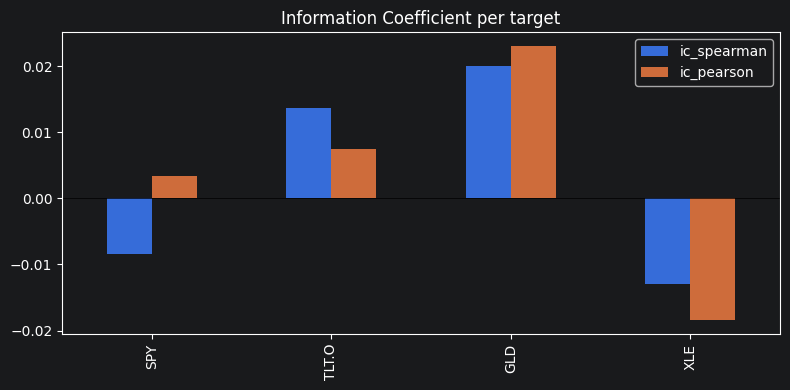

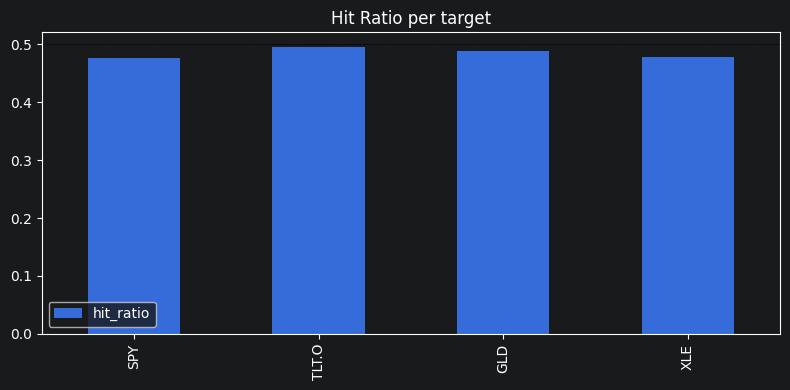

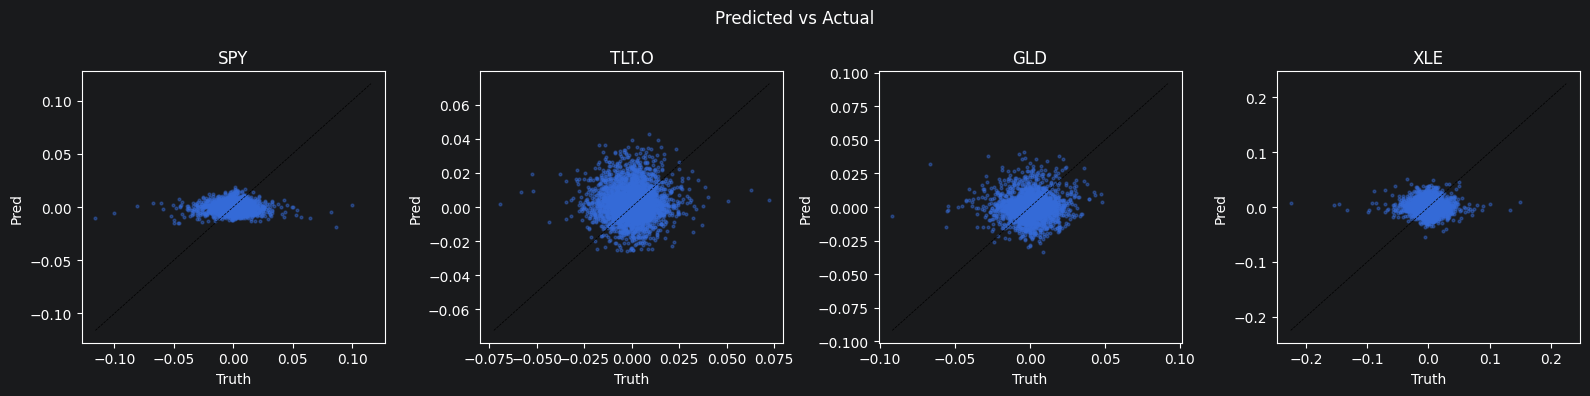

KeyError: 'fold_history'

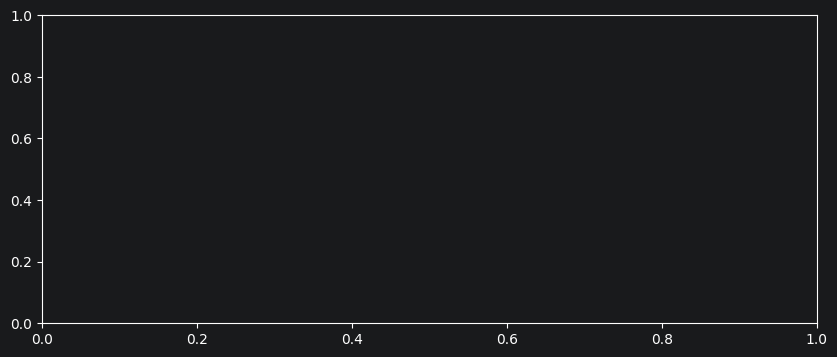

In [37]:
validation_df = pd.DataFrame(
    {t: validation_metrics(r["preds"]) for t, r in fold_results.items()}
).T
print(validation_df.round(5))

# (1) IC
validation_df[["ic_spearman", "ic_pearson"]].plot.bar(figsize=(8, 4), title="Information Coefficient per target")
plt.axhline(0, color="k", lw=0.5); plt.tight_layout(); plt.show()

# (2) Hit ratio
validation_df[["hit_ratio"]].plot.bar(figsize=(8, 4), title="Hit Ratio per target")
plt.axhline(0.5, color="k", ls="--", lw=0.5); plt.tight_layout(); plt.show()

# (3) Predicted vs Actual scatter (per target)
fig, axes = plt.subplots(1, len(TARGET_TICKERS), figsize=(4 * len(TARGET_TICKERS), 4))
axes = axes if len(TARGET_TICKERS) > 1 else [axes]
for ax, t in zip(axes, TARGET_TICKERS):
    df = fold_results[t]["preds"]
    ax.scatter(df["truth"], df["pred"], s=4, alpha=0.4)
    lim = max(df["truth"].abs().max(), df["pred"].abs().max())
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
    ax.set_title(t); ax.set_xlabel("Truth"); ax.set_ylabel("Pred")
plt.suptitle("Predicted vs Actual"); plt.tight_layout(); plt.show()

# (4) Fold-level Hit ratio stability
fig, ax = plt.subplots(figsize=(10, 4))
for t in TARGET_TICKERS:
    fh = fold_results[t]["fold_history"].set_index("test_start")
    fh["hit"].plot(ax=ax, marker="o", ms=3, label=t)
ax.axhline(0.5, color="k", ls="--", lw=0.5)
ax.set_title("Hit ratio across folds"); plt.legend(); plt.tight_layout(); plt.show()

# (5) Feature selection frequency
combined = {}
for r in fold_results.values():
    for f, c in r["feature_counts"].items():
        combined[f] = combined.get(f, 0) + c
pd.Series(combined).sort_values().tail(15).plot.barh(
    figsize=(8, 5), title="Top-15 feature selection frequency (all targets, all folds)"
)
plt.tight_layout()
plt.show()

validation_df.round(5)

In [ ]:
# Actual vs. Predicted time series per target
# Uses fold_results if available in memory, otherwise loads from a saved run_dir
date_range = [-400, -1]
try:
    _results = fold_results
    _run_dir = run_dir
except NameError:
    _run_dir = "../model/YYYYMMDD_HHMMSS"   # ← replace with your folder
    _results = load_results(_run_dir)

for target, r in _results.items():
    preds_df = r["preds"]
    safe = target.replace(".", "_")
    ax = preds_df[date_range[0]:date_range[1]].plot(y=["truth", "pred"], figsize=(12, 6), alpha=0.7,
                       title=f"{target} — Actual vs. Predicted (t+1 log return)")
    ax.set_xlabel("Date")
    ax.grid(True)
    ax.axhline(0, color="k", lw=0.5, ls="--")
    plt.tight_layout()
    plt.savefig(f"{_run_dir}/{safe}_pred_vs_actual.png", dpi=100)
    plt.show()


In [ ]:
# VSN Weights over time
for target, r in _results.items():
    if "vsn_weights" in r and not r["vsn_weights"].empty:
        weights_df = r["vsn_weights"]
        safe = target.replace(".", "_")
        ax = weights_df[date_range[0]:date_range[1]].plot(figsize=(12, 6), alpha=0.8,
                           title=f"{target} — VSN Attention Weights over time")
        ax.set_xlabel("Date")
        ax.set_ylabel("Attention Weight")
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig(f"{_run_dir}/{safe}_vsn_weights.png", dpi=100)
        plt.show()

# Backtesting


In [39]:
def backtest(preds_df, threshold=0.0):
    p = preds_df["pred"]
    t = preds_df["truth"]
    position = np.sign(p)
    if threshold > 0:
        position = position.where(p.abs() > threshold, 0)
    strat_ret = position * t
    bench_ret = t
    return pd.DataFrame({
        "position": position,
        "strat_ret": strat_ret,
        "bench_ret": bench_ret,
        "strat_eq": np.exp(strat_ret.cumsum()),
        "bench_eq": np.exp(bench_ret.cumsum()),
    }, index=preds_df.index)

In [40]:
def perf_metrics(ret, periods=252):
    ret = ret.dropna()
    if len(ret) == 0:
        return {}
    equity = np.exp(ret.cumsum())
    ann_ret = ret.mean() * periods
    ann_vol = ret.std() * np.sqrt(periods)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
    downside = ret[ret < 0].std() * np.sqrt(periods)
    sortino = ann_ret / downside if downside > 0 else 0.0
    dd = float((equity / equity.cummax() - 1).min())
    total_ret = float(equity.iloc[-1]) - 1
    years = len(ret) / periods
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0
    calmar = cagr / abs(dd) if dd < 0 else 0.0
    return {
        "total_return": float(total_ret),
        "cagr": float(cagr),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe),
        "sortino": float(sortino),
        "max_drawdown": dd,
        "calmar": float(calmar),
        "win_rate": float((ret > 0).mean()),
    }

        strat_total_return  strat_cagr  strat_ann_vol  strat_sharpe  \
target                                                                
SPY                -0.4142     -0.0316         0.1698       -0.1890   
TLT.O               0.7848      0.0354         0.1483        0.2344   
GLD                 0.5607      0.0271         0.1561        0.1711   
XLE                -0.4050     -0.0307         0.2695       -0.1156   

        strat_sortino  strat_max_drawdown  strat_calmar  strat_win_rate  \
target                                                                    
SPY           -0.2490             -0.6333       -0.0499          0.4769   
TLT.O          0.3525             -0.3381        0.1046          0.4960   
GLD            0.2531             -0.3901        0.0694          0.4886   
XLE           -0.1476             -0.8449       -0.0363          0.4783   

        bench_total_return  bench_cagr  bench_ann_vol  bench_sharpe  \
target                                             

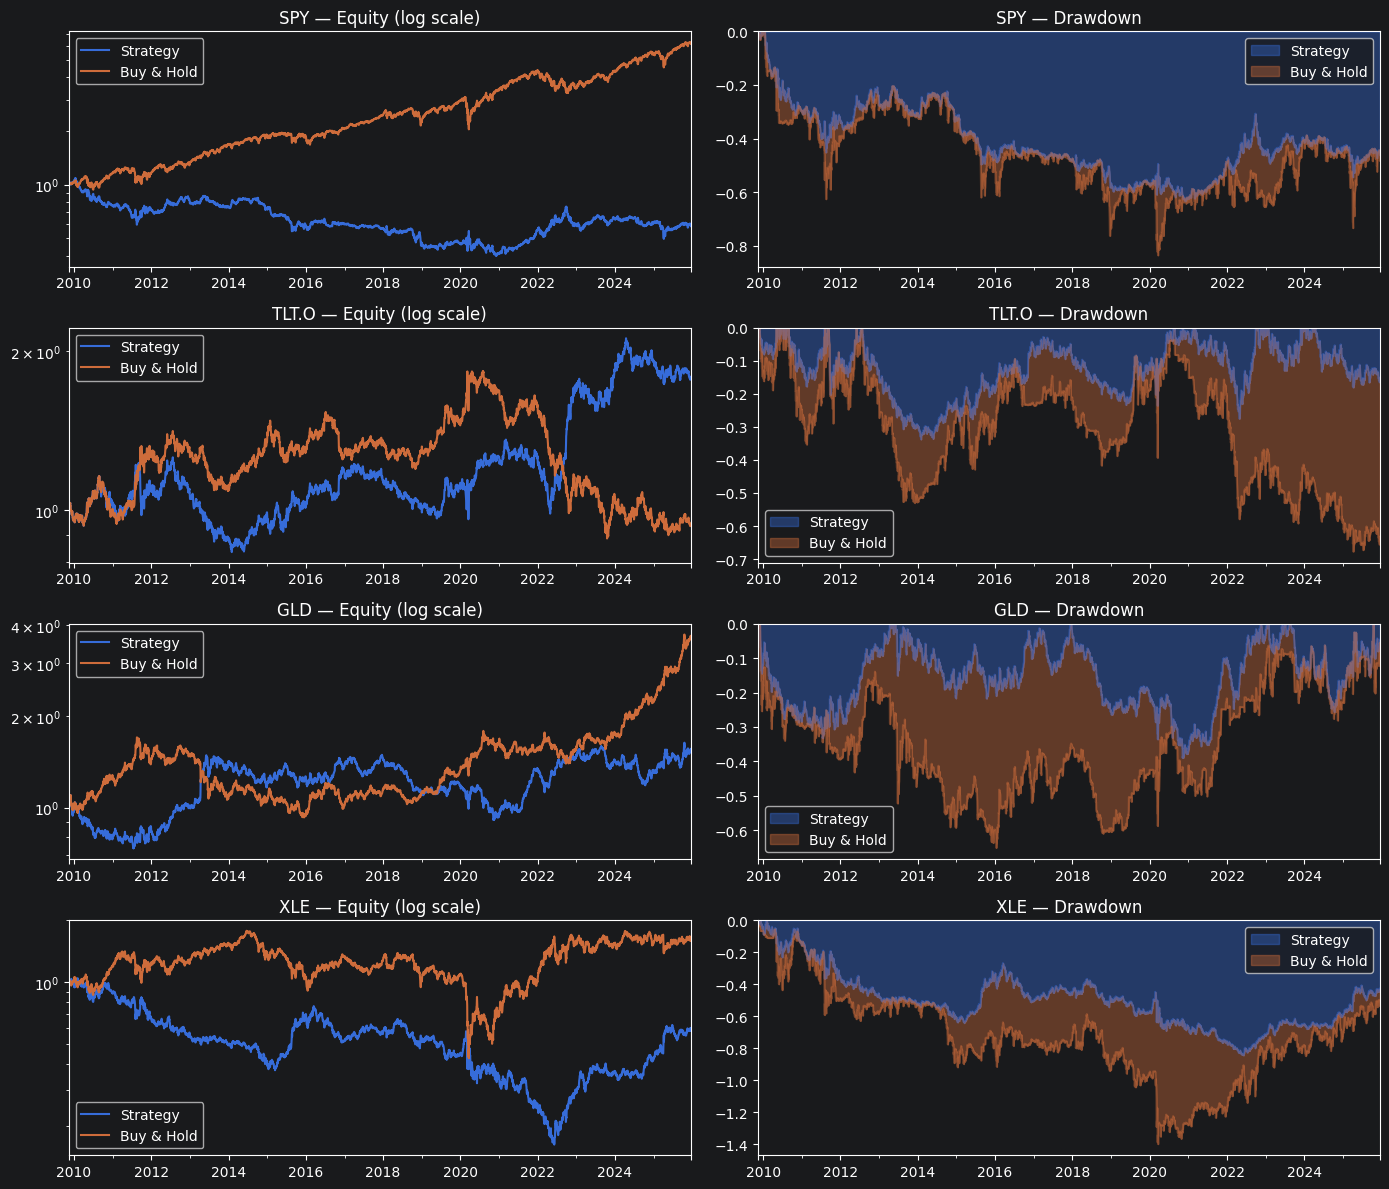

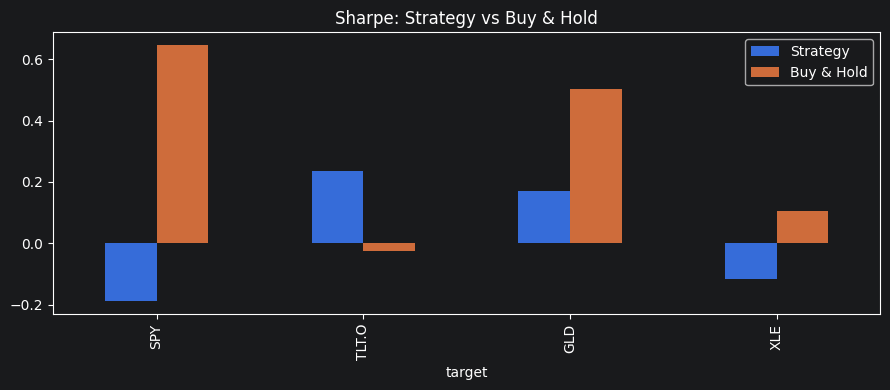

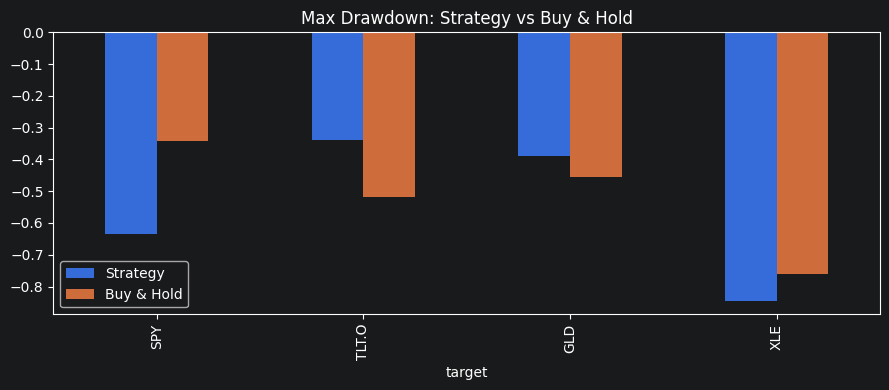

,strat_total_return,strat_cagr,strat_ann_vol,strat_sharpe,strat_sortino,strat_max_drawdown,strat_calmar,strat_win_rate,bench_total_return,bench_cagr,bench_ann_vol,bench_sharpe,bench_sortino,bench_max_drawdown,bench_calmar,bench_win_rate
target,,,,,,,,,,,,,,,,
SPY,-0.4142,-0.0316,0.1698,-0.1890,-0.2490,-0.6333,-0.0499,0.4769,5.2044,0.1157,0.1697,0.6455,0.7654,-0.3410,0.3394,0.5307
TLT.O,0.7848,0.0354,0.1483,0.2344,0.3525,-0.3381,0.1046,0.4960,-0.0564,-0.0035,0.1483,-0.0235,-0.0344,-0.5176,-0.0067,0.4979
GLD,0.5607,0.0271,0.1561,0.1711,0.2531,-0.3901,0.0694,0.4886,2.6833,0.0814,0.1560,0.5015,0.6578,-0.4556,0.1786,0.5100
XLE,-0.4050,-0.0307,0.2695,-0.1156,-0.1476,-0.8449,-0.0363,0.4783,0.5973,0.0285,0.2695,0.1043,0.1289,-0.7603,0.0375,0.4948


In [41]:
backtest_results = {t: backtest(r["preds"]) for t, r in fold_results.items()}

perf_rows = []
for t, bt in backtest_results.items():
    strat = perf_metrics(bt["strat_ret"])
    bench = perf_metrics(bt["bench_ret"])
    row = {"target": t}
    row.update({f"strat_{k}": v for k, v in strat.items()})
    row.update({f"bench_{k}": v for k, v in bench.items()})
    perf_rows.append(row)
perf_df = pd.DataFrame(perf_rows).set_index("target")
print(perf_df.round(4))

# Equity curves + drawdowns per target
fig, axes = plt.subplots(len(TARGET_TICKERS), 2, figsize=(14, 3 * len(TARGET_TICKERS)))
axes = axes.reshape(len(TARGET_TICKERS), 2)
for i, t in enumerate(TARGET_TICKERS):
    bt = backtest_results[t]
    bt[["strat_eq", "bench_eq"]].rename(columns={"strat_eq": "Strategy", "bench_eq": "Buy & Hold"}).plot(
        ax=axes[i, 0], logy=True, title=f"{t} — Equity (log scale)"
    )
    pd.DataFrame({
        "Strategy": bt["strat_eq"] / bt["strat_eq"].cummax() - 1,
        "Buy & Hold": bt["bench_eq"] / bt["bench_eq"].cummax() - 1,
    }).plot.area(ax=axes[i, 1], alpha=0.4, title=f"{t} — Drawdown")
plt.tight_layout(); plt.show()

# Sharpe + Max DD summary
perf_df[["strat_sharpe", "bench_sharpe"]].rename(
    columns={"strat_sharpe": "Strategy", "bench_sharpe": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Sharpe: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

perf_df[["strat_max_drawdown", "bench_max_drawdown"]].rename(
    columns={"strat_max_drawdown": "Strategy", "bench_max_drawdown": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Max Drawdown: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

perf_df.round(4)